# Journal Recommendation System
**Data Mining Final Project**

**Student**: Ali Berk Yeşilduman  
**Student ID**: 20200808035  
**Email**: 20200808035@ogr.akdeniz.edu.tr  

This notebook documents the final delivery pipeline. The selected recommendation method is a TF-IDF and cosine-similarity baseline, while the selected topic clustering model is the accepted `K=46` K-Means solution chosen after a broad K-selection study.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd

sys.path.append(os.path.abspath('..'))

from src.clustering import TopicClusterer
from src.database import load_data
from src.final_config import (
    ACCEPTED_KNEEDLE_K,
    FINAL_CLUSTER_K,
    FINAL_K_COMPARISON_VALUES,
    K_SELECTION_VALUES,
    SAMPLE_ABSTRACT,
    SAMPLE_SIZE_SILHOUETTE,
)
from src.preprocessing import preprocess_dataframe
from src.recommender import JournalRecommender

## 1. Data Loading and Preprocessing
We build a combined text field from abstracts, author keywords, Web of Science subjects, and keyword plus terms. The text is lowercased, stripped of HTML, purged of non-alphabetic characters, and normalized for whitespace.

In [2]:
db_path = '../data/CompSciencePub.sqlite'
df = load_data(db_path)
df = preprocess_dataframe(df)
print(f'Total articles loaded: {len(df)}')
df[['article_id', 'journal_name', 'abstract']].head(3)

Cleaning text data. This might take a moment...


Total articles loaded: 23061


,article_id,journal_name,abstract
0,88652,ACM COMPUTING SURVEYS,<p>After using evolutionary techniques for sin...
1,88653,ACM COMPUTING SURVEYS,<p>Distributed data processing is becoming a r...
2,88654,ACM COMPUTING SURVEYS,<p>Logical models of argument formalize common...


## 2. Exploratory Data Analysis
These charts summarize the corpus before recommendation and clustering.

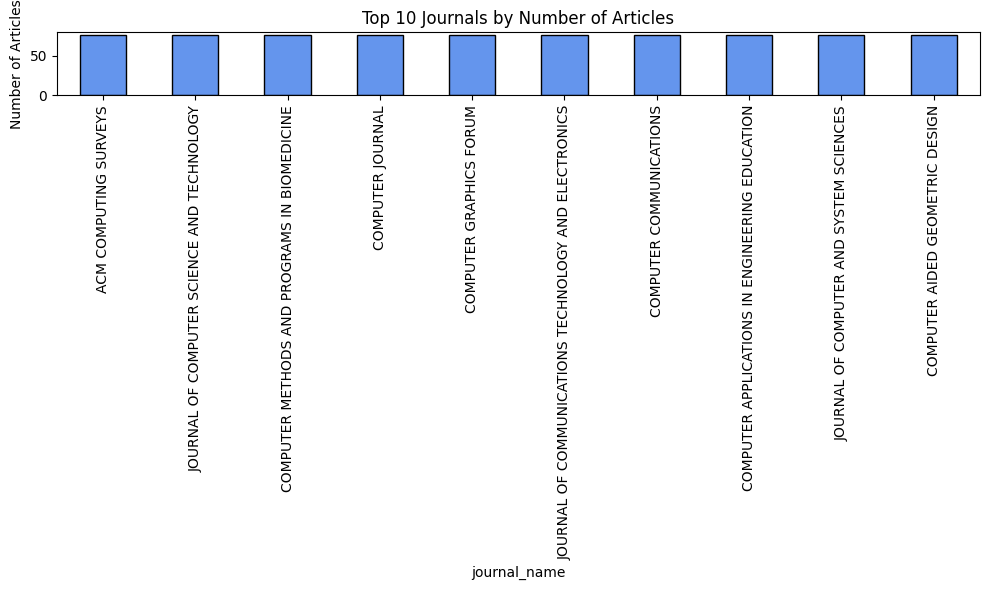

In [3]:
plt.figure(figsize=(10, 6))
df['journal_name'].value_counts().head(10).plot(kind='bar', color='cornflowerblue', edgecolor='black')
plt.title('Top 10 Journals by Number of Articles')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.show()

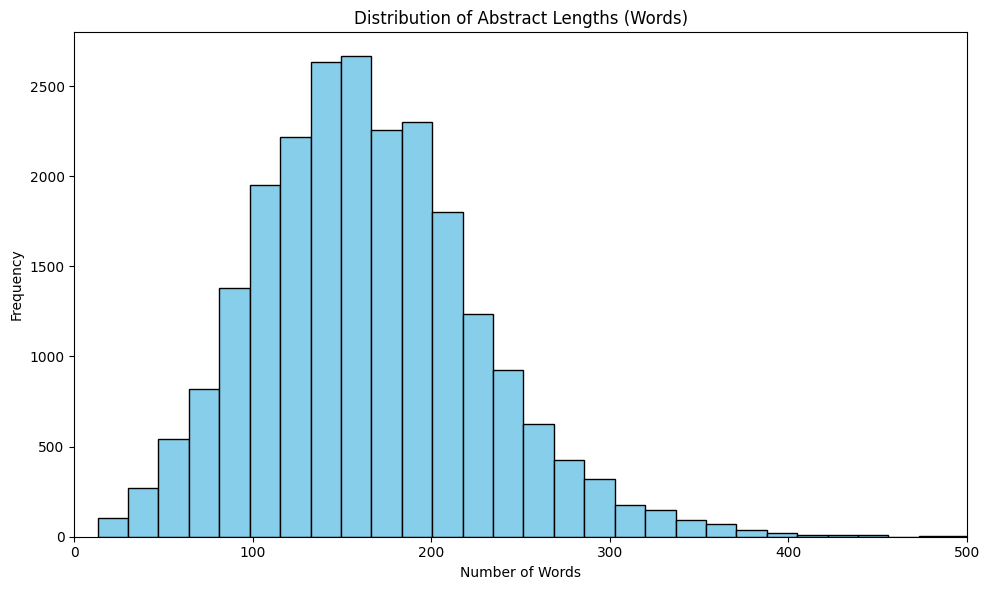

In [4]:
df['abstract_length'] = df['abstract'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
df['abstract_length'].plot(kind='hist', bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Abstract Lengths (Words)')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.xlim(0, 500)
plt.tight_layout()
plt.show()

## 3. Journal Recommendation Pipeline
The recommender fits a TF-IDF representation over the cleaned document text and ranks journals with a weighted combination of maximum and average cosine similarity.

## 4. Journal Recommendation Example
In this step, a sample article abstract is given to the trained recommender system.  
The system ranks journals using TF-IDF cosine similarity and returns the top 5 most relevant journals.

In [5]:
print("Sample abstract used for journal recommendation:")
print(SAMPLE_ABSTRACT)

recommender = JournalRecommender(max_features=10000)
recommender.fit(df)

recs = recommender.recommend_journals(SAMPLE_ABSTRACT, top_n=5)
print("\nTop-5 recommended journals:")
recs[['journal_name', 'score', 'max_similarity', 'avg_similarity']]

Sample abstract used for journal recommendation:
This paper proposes a machine learning based method for detecting anomalies in network traffic using deep neural networks and feature selection techniques.
Fitting TF-IDF Vectorizer...


TF-IDF Matrix shape: (23061, 10000)

Top-5 recommended journals:


,journal_name,score,max_similarity,avg_similarity
0,ACM SIGCOMM COMPUTER COMMUNICATION REVIEW,0.243173,0.328831,0.043303
1,KNOWLEDGE AND INFORMATION SYSTEMS,0.235269,0.317961,0.042322
2,FRONTIERS OF INFORMATION TECHNOLOGY & ELECTRON...,0.234296,0.311165,0.054937
3,IEEE WIRELESS COMMUNICATIONS,0.233596,0.320958,0.029753
4,INTERNATIONAL JOURNAL OF COMPUTERS COMMUNICATI...,0.232698,0.321227,0.026129


## 5. Hold-Out Evaluation
The recommendation model is evaluated with a stratified 80/20 split over journals that have at least five articles.

In [6]:
metrics = recommender.evaluate(
    df=df,
    test_size=0.2,
    min_journal_articles=5,
    random_state=42,
)
pd.DataFrame([metrics])

Fitting TF-IDF Vectorizer...


TF-IDF Matrix shape: (18384, 10000)


,eligible_rows,eligible_journals,train_rows,test_rows,top1_accuracy,top3_accuracy,top5_accuracy,mrr
0,22980,406,18384,4596,0.283725,0.458877,0.549608,0.410201


## 6. K Selection Analysis for Topic Clustering
The clustering feature space uses domain-aware TF-IDF, TruncatedSVD, and L2 normalization. We scanned `K=2..100` with step `2`, plus the manually compared `K=45`, and accepted `K=46` as the elbow-based final operating point.

In [7]:
probe_clusterer = TopicClusterer(random_state=42)
k_selection_results = probe_clusterer.evaluate_k_values(
    df,
    text_column='clean_text',
    k_values=K_SELECTION_VALUES,
    sample_size=SAMPLE_SIZE_SILHOUETTE,
)

shortlist = (
    k_selection_results[k_selection_results['k'].isin(FINAL_K_COMPARISON_VALUES)]
    .sort_values('k')
    .reset_index(drop=True)
)
shortlist

Building clustering features...


,k,silhouette_score,inertia,davies_bouldin_score,calinski_harabasz_score,min_cluster_size,median_cluster_size,max_cluster_size,clusters_under_150,clusters_under_100
0,36,0.172937,10096.533991,1.915725,592.691799,260,641.0,1221,0,0
1,40,0.179920,9609.115232,1.795801,588.728399,151,570.5,1010,0,0
2,44,0.185852,9214.363271,1.750828,579.673370,116,523.5,908,1,0
3,45,0.181592,9174.053818,1.766131,571.261754,150,492.0,937,0,0
4,46,0.184819,9058.067181,1.748366,572.243740,118,478.0,898,1,0
5,48,0.186396,8930.956006,1.765109,562.611473,152,475.5,886,0,0
6,50,0.189647,8747.151163,1.688724,560.807545,117,420.0,851,1,0


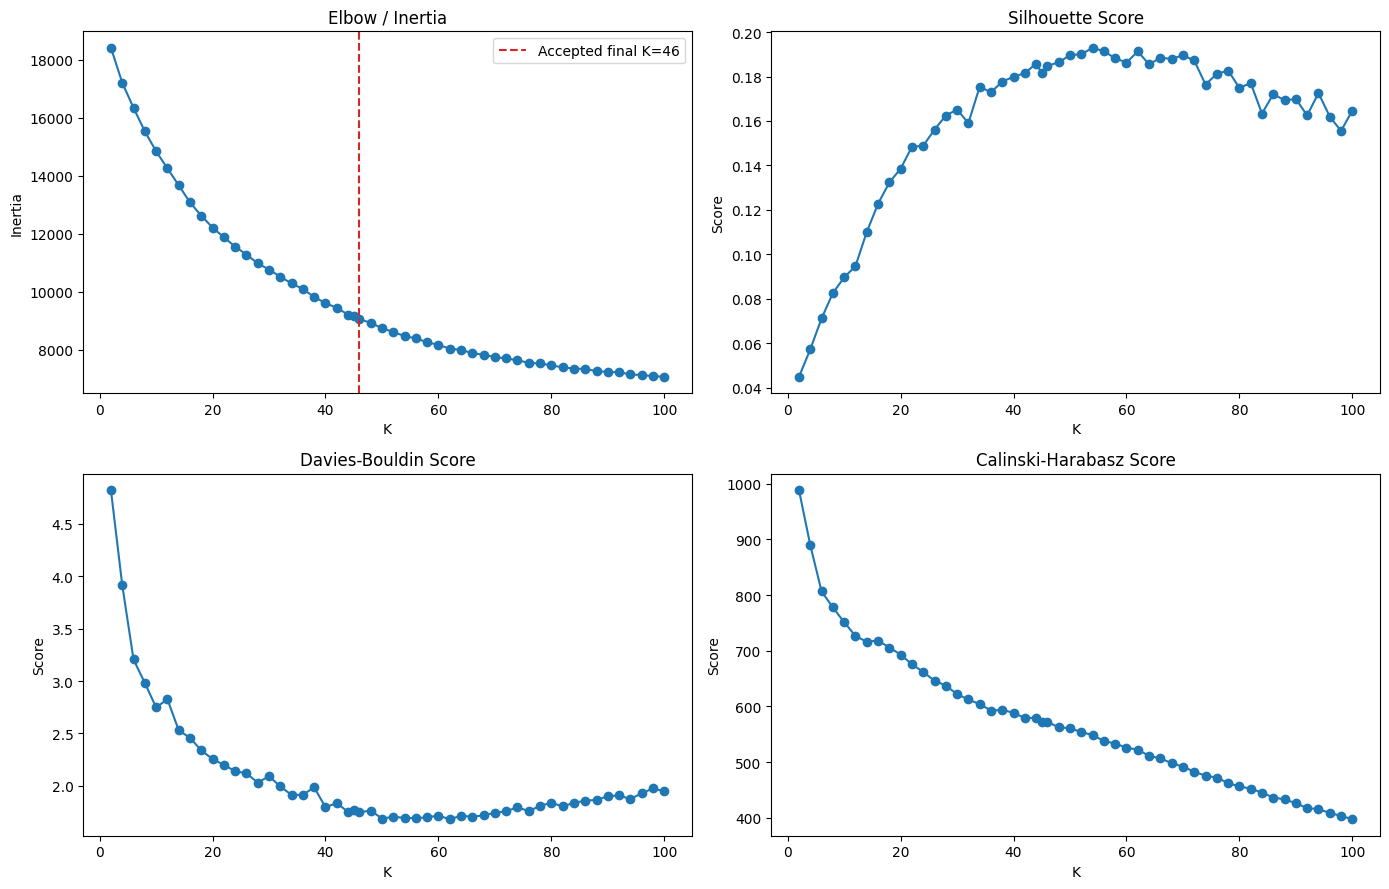

Accepted elbow / Kneedle decision: K=46. The final delivery uses K=46.


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(k_selection_results['k'], k_selection_results['inertia'], marker='o')
axes[0, 0].axvline(FINAL_CLUSTER_K, color='tab:red', linestyle='--', label=f'Accepted final K={FINAL_CLUSTER_K}')
axes[0, 0].set_title('Elbow / Inertia')
axes[0, 0].set_xlabel('K')
axes[0, 0].set_ylabel('Inertia')
axes[0, 0].legend()

axes[0, 1].plot(k_selection_results['k'], k_selection_results['silhouette_score'], marker='o')
axes[0, 1].set_title('Silhouette Score')
axes[0, 1].set_xlabel('K')
axes[0, 1].set_ylabel('Score')

axes[1, 0].plot(k_selection_results['k'], k_selection_results['davies_bouldin_score'], marker='o')
axes[1, 0].set_title('Davies-Bouldin Score')
axes[1, 0].set_xlabel('K')
axes[1, 0].set_ylabel('Score')

axes[1, 1].plot(k_selection_results['k'], k_selection_results['calinski_harabasz_score'], marker='o')
axes[1, 1].set_title('Calinski-Harabasz Score')
axes[1, 1].set_xlabel('K')
axes[1, 1].set_ylabel('Score')

plt.tight_layout()
plt.show()

print(
    f'Accepted elbow / Kneedle decision: K={ACCEPTED_KNEEDLE_K}. '
    f'The final delivery uses K={FINAL_CLUSTER_K}.'
)

## 7. Final `K=46` Clustering Model
After the broad scan, the final K-Means model is fit with `K=46` and summarized with representative top terms per cluster.

In [9]:
clusterer = TopicClusterer(n_clusters=FINAL_CLUSTER_K, random_state=42)
clustered_df = clusterer.fit_predict(df, text_column='clean_text')
cluster_summary = clusterer.get_cluster_summary(clustered_df, top_n=10)
cluster_summary

Building clustering features...


Clustering into 46 topics using K-Means...


,cluster,size,top_terms
0,0,118,"history philosophy, history, philosophy, theor..."
1,1,391,"routing, hoc, ad hoc, ad, networks, hoc networ..."
2,2,522,"telecommunications, telecommunications enginee..."
3,3,316,"feature, selection, feature selection, feature..."
4,4,388,"trust, perceived, acceptance, technology, onli..."
5,5,898,"hardware, architecture, memory, performance, h..."
6,6,352,"optimization, swarm, particle, algorithm, part..."
7,7,729,"biology, computational biology, mathematical c..."
8,8,634,"network, traffic, networks, optical, telecommu..."
9,9,841,"element, finite, finite element, numerical, fl..."


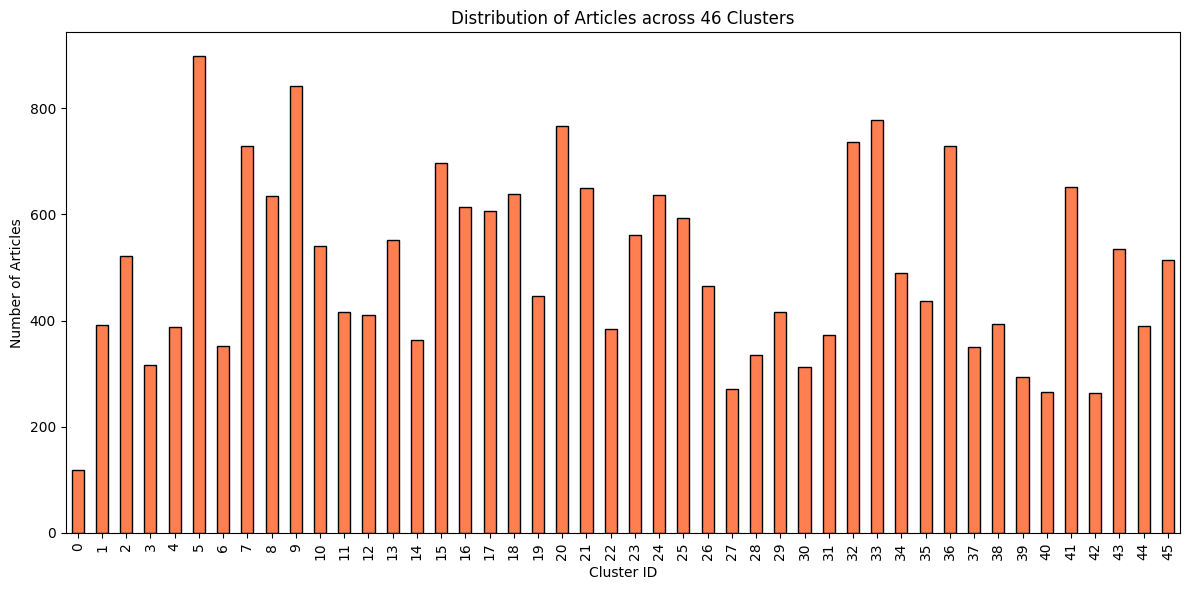

In [10]:
plt.figure(figsize=(12, 6))
clustered_df['cluster'].value_counts().sort_index().plot(kind='bar', color='coral', edgecolor='black')
plt.title(f'Distribution of Articles across {FINAL_CLUSTER_K} Clusters')
plt.xlabel('Cluster ID')
plt.ylabel('Number of Articles')
plt.tight_layout()
plt.show()

Reducing dimensions for visualization...


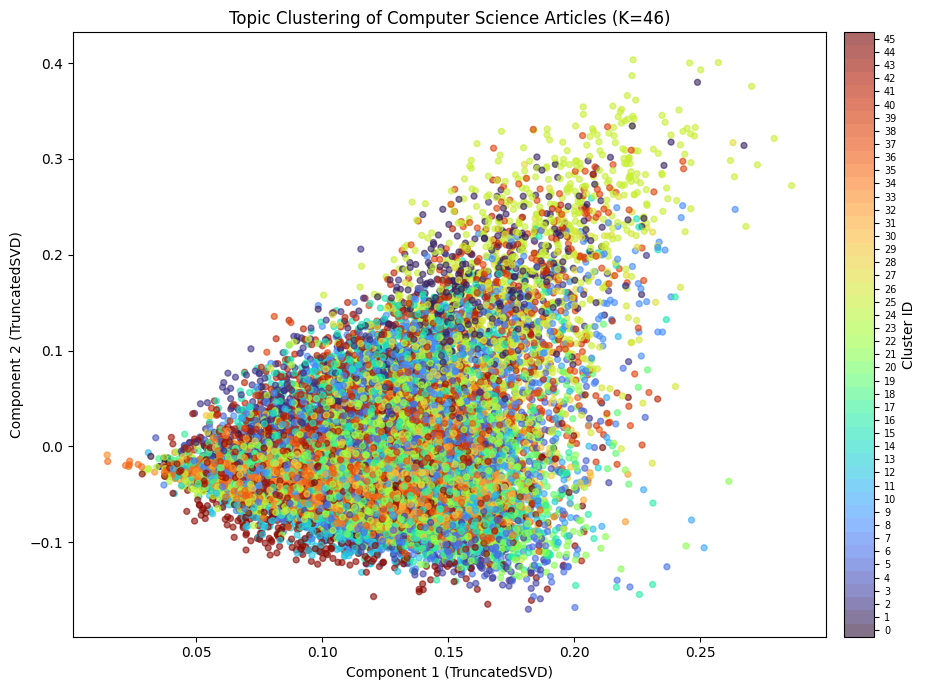

SVD explained variance (2 components): 0.0069


In [11]:
plot_df, explained_variance = clusterer.visualize_clusters(clustered_df, show=True)
print(f'SVD explained variance (2 components): {explained_variance:.4f}')

## 8. Alternative Method Explored
An experimental BERTopic pipeline was also evaluated with two embedding backends: TF-IDF + TruncatedSVD and sentence-transformer embeddings. The final submission keeps K-Means as the chosen model because it is deterministic, easier to explain, and does not discard a large fraction of documents as outliers.

In [12]:
alternative_summary_path = '../outputs/alternative_method_summary.csv'
if os.path.exists(alternative_summary_path):
    alternative_summary = pd.read_csv(alternative_summary_path)
    display(alternative_summary)
else:
    alternative_summary = pd.DataFrame({
        "method": ["BERTopic (TF-IDF + SVD)", "BERTopic (sentence-transformer)"],
        "topics": [52, 41],
        "outliers": [3234, 4449],
        "outlier_ratio": [0.1402, 0.1929],
    })
    display(alternative_summary)

,method,backend,documents,assigned_topics_excluding_outliers,outlier_documents,outlier_ratio_pct,largest_topic_size,smallest_topic_size
0,BERTopic (TF-IDF + TruncatedSVD),tfidf_svd,23061,52,3234,14.023676,1400,152
1,BERTopic (sentence-transformer/all-MiniLM-L6-v2),sentence_transformer,23061,41,4449,19.292312,2141,153


## 9. Final Notes
The final delivery is organized around one selected clustering decision (`K=46`), one accepted recommendation pipeline, and one clearly separated experimental alternative. This keeps the submission focused while still documenting the explored alternatives and the reasoning behind the final choice.